# Topic 18: Bode Design Approach

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [15]:
colors = bm.get_colors()
j = complex(0,1)

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## 18-7 Kv calc


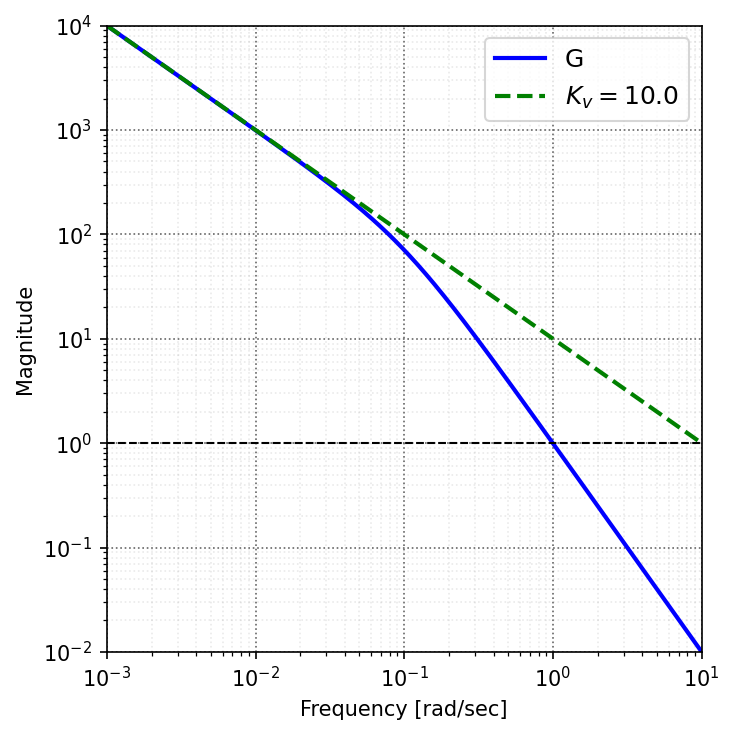

In [16]:
w = np.logspace(-3,1,500)
G = ct.tf([1],[1,.1,0])
Kv = cm.find_Kv(G)
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,sharex=True)
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
ax.loglog(Gw,Gm,'b-',label='G')
ax.loglog(Gw,Kv/Gw,'g--',label='$K_v={:3.1f}$'.format(Kv))
ax.legend(fontsize=12)
ax.set_ylim([1e-2,1e4])
ax.set_xlim([1e-3,1e1])
ax.set_ylabel("Magnitude")
ax.set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L16_Kv.pdf',dpi=600)
plt.show()


# Lead Design On 18-13

In [17]:
w = np.logspace(-1,np.log10(100),500)
G = ct.tf([10],[1,1,0])
Kv = cm.find_Kv(G)

PMdes = 40
wc_des = 10
w = np.sort(np.append(np.logspace(-1,3,500),wc_des))

phi_G = -180. # approx
phi_m = (PMdes - (180 + phi_G))/cm.r2d
print(f"Required phase boost: {phi_m*cm.r2d:.2f} deg")
zdp = (1-np.sin(phi_m))/(1+np.sin(phi_m))
z = wc_des*np.sqrt(zdp)
p = z/zdp
Gc_lead = ct.tf([1, z],[1, p]) 
L = G*Gc_lead
k_c = 1/np.abs(L(j*wc_des))
Gc_lead *= k_c
cm.show_tf_latex(Gc_lead, name='G_c^{lead}',show=True,factor=True)
L = G*Gc_lead

Required phase boost: 40.00 deg


<IPython.core.display.Math object>

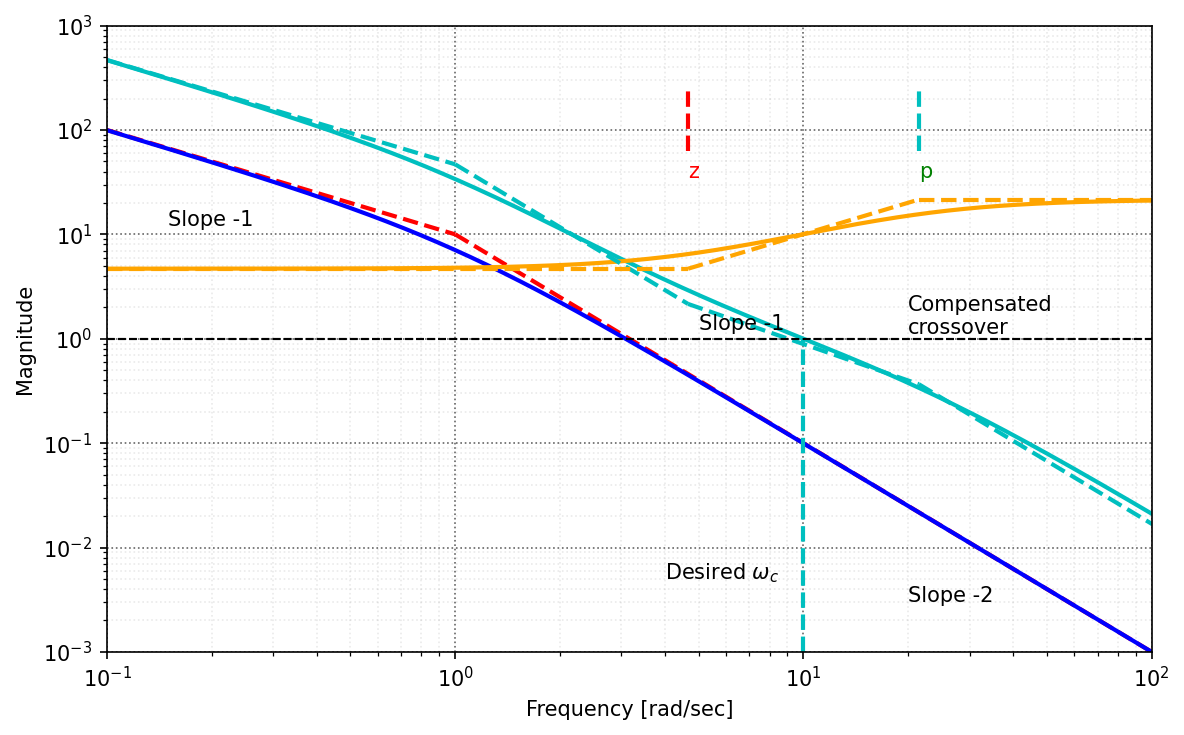

In [18]:
fig, ax = plt.subplots(1,figsize=(5,5),dpi=150,sharex=True)
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[Gcm,Gcp,Gcw] = ct.frequency_response(Gc_lead,omega=w)
ax.loglog((np.min(w),1),(Kv/np.min(w),Kv/1),'r--',label='G')
ax.loglog((1,max(w)),(Kv/1,Kv/max(w)**2),'r--',label='G')
ax.loglog(Gw,Gm,'b-',label='G')
ax.text(4,5e-3,r'Desired $\omega_c$',fontsize=10)
ax.axvline(x=wc_des,ymin=0,ymax=.5,c='c',ls='--')
ax.set_ylabel("Magnitude")
ax.set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
ax.text(20,3e-3,'Slope -2',fontsize=10)
ax.text(.15,12,'Slope -1',fontsize=10)
ax.set_ylim([1e-3,1000])
ax.set_xlim([1e-1,1e2])
plt.savefig('./figs/L16_12a.pdf',dpi=600)

ax.loglog(Gw,Gm*Gcm,'c-',label='G')
ax.loglog(Gw,Gcm,'orange',label='Gc')

ax.loglog((np.min(w),1),(k_c*z/p*Kv/np.min(w),k_c*z/p*Kv/1),'c--',label='GGc')
ax.loglog((1,z),(k_c*z/p*Kv/1,k_c*z/p*Kv/z**2),'c--',label='GGc')
ax.loglog((z,p),(k_c*z/p*Kv/z**2,k_c*z/p*Kv/p**2*(p-z)/z),'c--',label='GGc')
ax.loglog((p,np.max(w)),(k_c*z/p*Kv/p**2*(p-z)/z,k_c*z/p*Kv/np.max(w)**2*(p-z)/z),'c--',label='GGc')

ax.loglog((min(w),z),(k_c*z/p,k_c*z/p),'orange',label='Gc',ls='--')
ax.loglog((z,p),(k_c*z/p,k_c),'orange',label='Gc',ls='--')
ax.loglog((p,np.max(w)),(k_c,k_c),'orange',label='Gc',ls='--')

ax.axvline(x=z,ymin=.8,ymax=.9,c='r',ls='--')
ax.text(z,35,'z',color='r',fontsize=10)
ax.axvline(x=p,ymin=.8,ymax=.9,c='c',ls='--')
ax.text(p,35,'p',color='g',fontsize=10)
ax.text(20,1.1,'Compensated\ncrossover',fontsize=10)
ax.text(5,1.2,'Slope -1',fontsize=10)
ax.set_ylim([1e-3,1000])
ax.set_xlim([1e-1,1e2])
bm.nicegrid(ax)
plt.savefig('./figs/L16_12.pdf',dpi=600)
fig.set_size_inches(8, 5)
plt.savefig('./figs/L16_12c.pdf',dpi=600)
plt.show()


Computed PM: 45.71


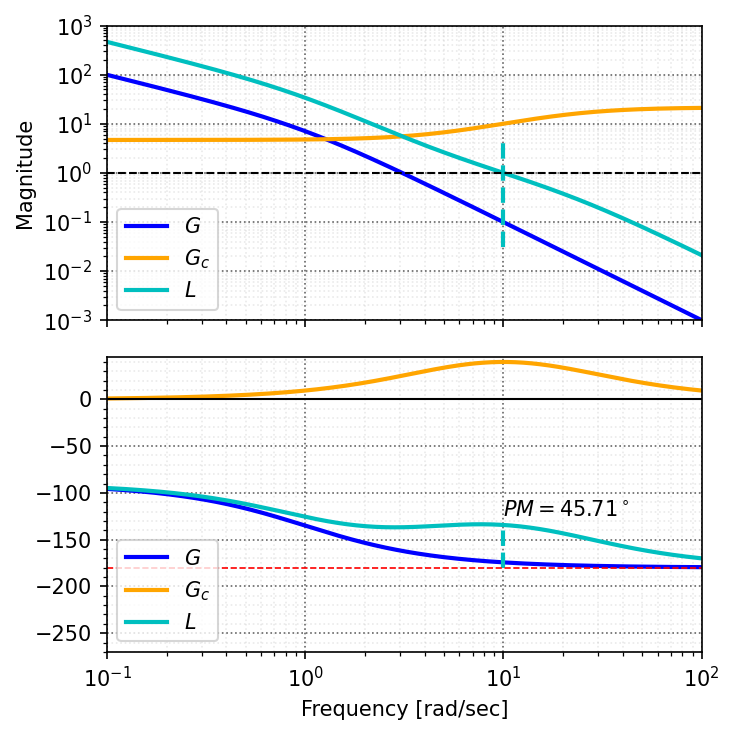

In [19]:
fig, ax = plt.subplots(2,1,figsize=(5,5),dpi=150,sharex=True)
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[Gcm,Gcp,Gcw] = ct.frequency_response(Gc_lead,omega=w)
[Lm,Lp,Lw] = ct.frequency_response(L,omega=w)

yl=-270;yh=45
ax[0].set_ylim([1e-3,1000])
ax[1].set_ylim([yl,yh])
ax[1].set_xlim([1e-1,1e2])

ax[0].loglog(Gw,Gm,'b-',label=r'$G$')
ax[0].loglog(Gcw,Gcm,'orange',label=r'$G_c$')
ax[0].loglog(Lw,Lm,'c-',label=r'$L$')
ax[0].axvline(x=wc_des,ymin=.25,ymax=.6,c='c',ls='--')

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label=r'$G$')
ax[1].semilogx(Gcw,Gcp*cm.r2d,'orange',label=r'$G_c$')
ax[1].semilogx(Lw,cm.wrap_phase_neg(Lp)*cm.r2d,'c-',label=r'$L$')

PMact,wc,_ = cm.find_PM(w,L)
print(f"Computed PM: {PMact:.2f}")
ax[1].text(wc,-180+PMact+10,rf"$PM = {PMact:.2f}^\circ$",fontsize=10)
ax[1].axvline(x=wc_des,ymin=(-yl-180)/(yh-yl),ymax=(-yl-180+PMact)/(yh-yl),c='c',ls='--')

ax[0].set_ylabel("Magnitude")
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].axhline(y=-180,c='r',ls='--',lw=0.8)
ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)
bm.nicegrid(ax)
plt.savefig('./figs/L16_13.pdf',dpi=600)
plt.show()


## Lead Example 
$$ G = \frac{10}{s(s^2+8s+15)} $$

In [25]:
G = ct.tf(10,np.convolve([1, 0],[1, 8, 15]))
wc_des = 5
PM_des = 40

Gf = G(j*wc_des)
phi_G = cm.wrap_phase_neg(np.angle(Gf))*cm.r2d
PM_init = 180+phi_G
print(f"Phase of the plant at {wc_des = :4.2f} rad/sec is {phi_G = :4.2f} degs")
print(f"Thus initial Phase Margin is {PM_init = :4.2f} degs")
print(f"Desired Phase Margin is {PM_des = :4.2f} degs")

# Design Lead to improve PM
phi_m = PM_des - PM_init
print(f"Required Phase to add is {phi_m = :4.2f} degs")
zdp = (1-np.sin(phi_m/cm.r2d))/(1+np.sin(phi_m/cm.r2d))
z = np.sqrt(wc_des**2*zdp)
p = z/zdp

Gc = ct.tf([1, z],[1, p]) 
L = G*Gc
k_c = 1/np.abs(L(j*wc_des)) # Gain to make L(jwc) = 1
Gc *= k_c # increase the gain of the compensator
cm.show_tf_latex(Gc, name='G_c',show=True,factor=True)
L *= k_c # increase the gain of the loop transfer function
PM_act,wc_act,_ = cm.find_PM(w,L)
print(f"Achieves crossover frequency: {wc_act:.2f} rad/sec with PM: {PM_act:.2f} degs")
Gcl = ct.feedback(L,1)

Phase of the plant at wc_des = 5.00 rad/sec is phi_G = -194.04 degs
Thus initial Phase Margin is PM_init = -14.04 degs
Desired Phase Margin is PM_des = 40.00 degs
Required Phase to add is phi_m = 54.04 degs


<IPython.core.display.Math object>

Achieves crossover frequency: 5.00 rad/sec with PM: 40.00 degs


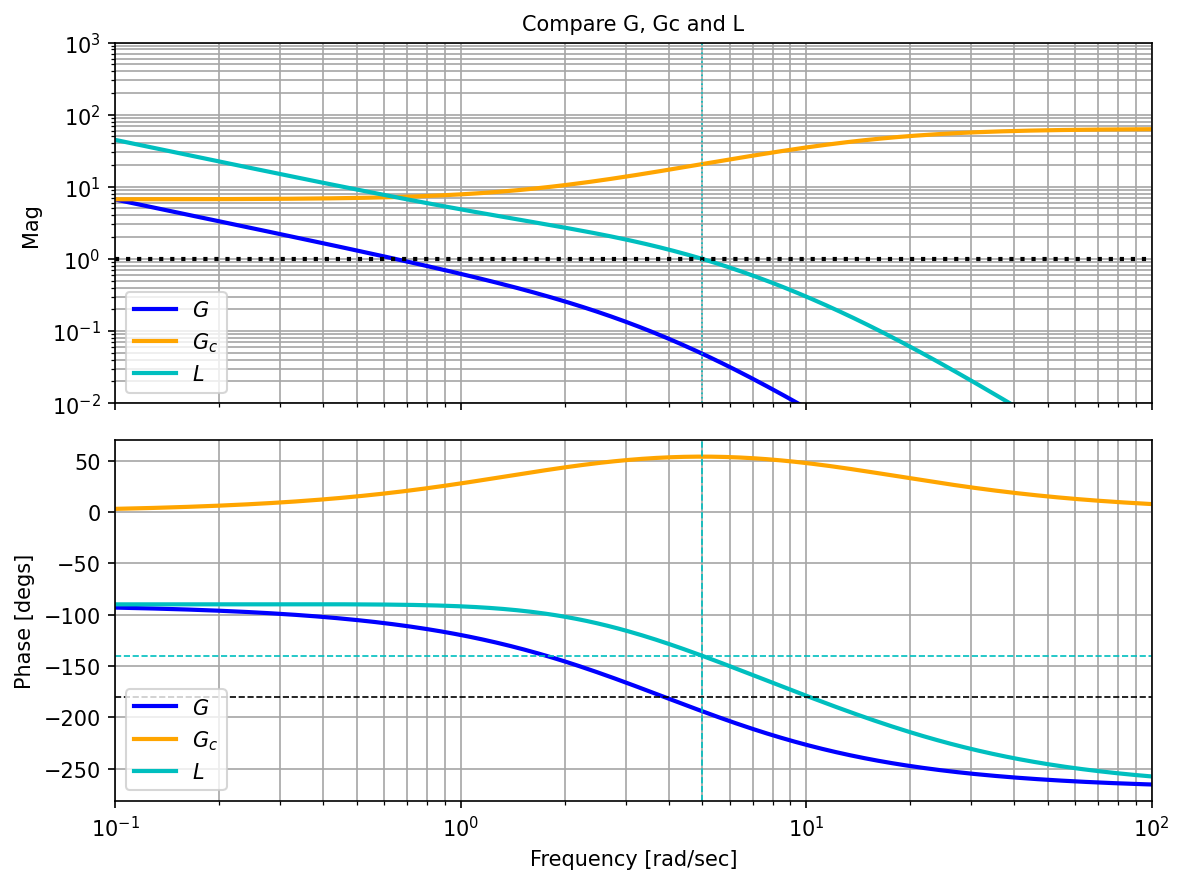

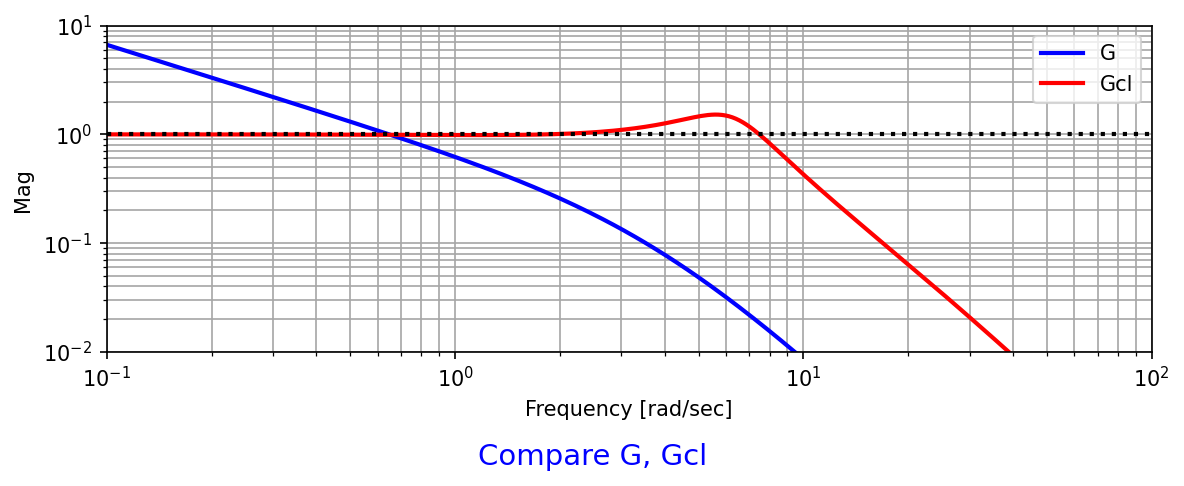

In [21]:
w = np.sort(np.append(np.logspace(-1,np.log10(100),300),wc)) #include wc in the frequency list

Gf = G(j*w); Gm = np.abs(Gf); Gp = np.angle(Gf); Gw = w;
Gcf = Gc(j*w); Gcm = np.abs(Gcf); Gcp = np.angle(Gcf); Gcw = w;
Lf = L(j*w); Lm = np.abs(Lf); Lp = np.angle(Lf); Lw = w;
Gclf = Gcl(j*w); Gclm = np.abs(Gclf); Gclp = np.angle(Gclf); Gclw = w;

fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label=r'$G$')
ax[0].loglog(Gcw,Gcm,c='orange',ls='-',label=r'$G_c$')
ax[0].loglog(Lw,Lm,ls='-',c='c',label=r'$L$')
ax[0].axhline(y=1,c='k',ls=":")
ax[0].axvline(x=wc_des,c='c',ls=":",lw=0.8)
ax[0].legend()
ax[0].set_ylim([.01,1000])
ax[0].set_ylabel("Mag ")

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label=r'$G$')
ax[1].semilogx(Gcw,Gcp*cm.r2d,c='orange',ls='-',label=r'$G_c$')
ax[1].semilogx(Lw,cm.wrap_phase_neg(Lp)*cm.r2d,ls='-',c='c',label=r'$L$')
ax[1].axhline(y=-180,c='k',ls="--",lw=0.8,)
ax[1].axhline(y=-180+PM_des,c='c',ls="--",lw=0.8)
ax[1].axvline(x=wc_des,c='c',ls="--",lw=0.8)
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
#ax[1].set_ylim([-270,0])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")
ax[0].set_title("Compare G, Gc and L")
plt.legend()
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
plt.show()

fig, ax = plt.subplots(1,figsize=(8, 3),dpi=150,sharex = True)
ax.loglog(Gw,Gm,'b-',label='G')
ax.loglog(Gclw,Gclm,c='red',ls='-',label='Gcl')
ax.axhline(y=1,c='k',ls=":")
ax.legend()
ax.set_ylim([.01,10])
ax.set_ylabel("Mag ")
ax.set_xlabel("Frequency [rad/sec]")
cm.caption("Compare G, Gcl",fig)
ax.grid(True, which="both", ls="-",color='0.65')
plt.show()

## Example using double lead 

In [22]:
G = ct.tf(1,[1, 1])**3
wc_des = 10
K = 1/np.abs(G(j*wc_des))
Gp = cm.r2d*cm.wrap_phase_neg(np.angle(G(j*wc_des)))
print(f"Plant phase is {Gp :3.1f} degs")
PM_G = 180 + Gp
print(f"Current PM {PM_G = :3.1f} degs")
# Apply gain to ensure that cross over is at wc_des
G = G*K 

# the goal PM - must be split for double lead
PM_goal = 35
PM_des = (35-PM_G)/2. # double lead
print(f"Phase to add per lead: {PM_des = :3.1f} degs")

w = np.sort(np.append(np.logspace(-1,3,300),wc_des))
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

Gc_lead = cm.lead_design(G, wc_des = wc_des, PMdes = PM_des)
# double lead
Gc_lead = Gc_lead*Gc_lead
PM_act = cm.r2d*np.angle(G(j*wc_des)*Gc_lead(j*wc_des)) + 180

Gf = G(j*w); Gm = np.abs(Gf); Gp = np.angle(Gf); Gw = w;
Gcff = Gc_lead(j*w); Gcm = np.abs(Gcff); Gcp = np.angle(Gcff); Gcw = w;
Lf = (G*Gc_lead)(j*w); Lm = np.abs(Lf); Lp = np.angle(Lf); Lw = w;
PM_act,wc_act,_ = cm.find_PM(w,Lf)

Plant phase is -252.9 degs
Current PM PM_G = -72.9 degs
Phase to add per lead: PM_des = 53.9 degs


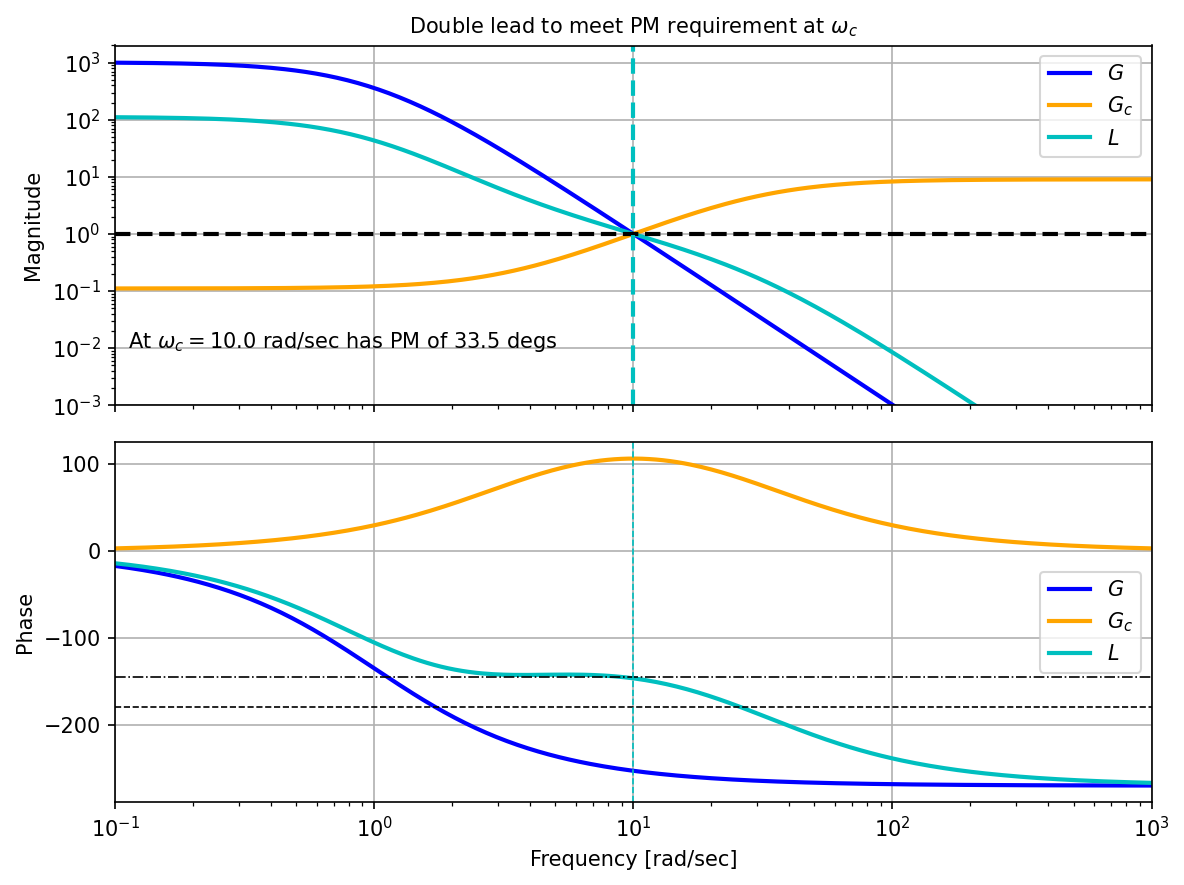

In [23]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label=r'$G$')
ax[0].loglog(Gcw,Gcm,ls='-',c='orange',label=r'$G_c$')
ax[0].loglog(Gw,Lm,c='c',ls='-',label=r'$L$')
ax[0].axhline(y=1,c='k',ls="--")
ax[0].axvline(x=wc_des,c='c',ls="--")
ax[0].text(min(w),.01,r'  At $\omega_c=${:3.1f} rad/sec has PM of {:3.1f} degs'.format(wc_act,PM_act),fontsize=10)
ax[0].legend()
ax[0].set_ylim([.001,2000])
ax[0].set_ylabel("Magnitude")

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label=r'$G$')
ax[1].semilogx(Gcw,cm.pshift(Gcp*cm.r2d),ls='-',c='orange',label=r'$G_c$')
ax[1].semilogx(Gw,cm.wrap_phase_neg(Lp)*cm.r2d,c='c',ls='-',label=r'$L$')
ax[1].axhline(y=-180,c='k',ls="--",lw=0.8)
ax[1].axhline(y=-180+PM_goal,c='k',ls="-.",lw=0.8)
ax[1].axvline(x=wc_des,c='c',ls="--",lw=0.8)
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
#ax[1].set_ylim([-270,0])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[0].set_title(r"Double lead to meet PM requirement at $\omega_c$")
plt.legend()
plt.savefig("./figs/E208_2_6.pdf", dpi=600)
plt.show()